# Power Transformer Health Index & Lifespan Prediction
## Hybrid Autoencoder-Enhanced Gradient Boosting Approach

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All packages loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")

All packages loaded successfully!
TensorFlow version: 2.21.0


## 2. Load & Explore Dataset

In [3]:
df = pd.read_csv('../data/health_index.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (470, 16)

Columns: ['Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor', 'Interfacial V', 'Dielectric rigidity', 'Water content', 'Health index', 'Life expectation']


,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0


In [5]:
print("   Dataset Info   ")
df.info()
print("\n   Statistics   ")
df.describe().round(2)

   Dataset Info   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hydrogen             470 non-null    int64  
 1   Oxigen               470 non-null    int64  
 2   Nitrogen             470 non-null    int64  
 3   Methane              470 non-null    int64  
 4   CO                   470 non-null    int64  
 5   CO2                  470 non-null    int64  
 6   Ethylene             470 non-null    int64  
 7   Ethane               470 non-null    int64  
 8   Acethylene           470 non-null    int64  
 9   DBDS                 470 non-null    float64
 10  Power factor         470 non-null    float64
 11  Interfacial V        470 non-null    int64  
 12  Dielectric rigidity  470 non-null    int64  
 13  Water content        470 non-null    int64  
 14  Health index         470 non-null    float64
 15  Life expectation     

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
count,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00
mean,404.26,8357.37,47759.56,79.70,244.00,1816.41,162.92,81.94,91.49,17.04,1.85,38.43,53.50,16.28,27.50,33.01
std,2002.14,14164.23,13760.45,489.32,237.27,2256.79,1323.81,342.57,644.37,46.74,6.14,6.18,6.46,17.12,17.74,17.79
min,0.00,57.00,3600.00,0.00,10.00,48.00,0.00,0.00,0.00,0.00,0.05,21.00,27.00,0.00,13.40,6.00
25%,4.00,496.00,41700.00,2.00,66.00,641.75,0.00,0.00,0.00,0.00,0.57,32.00,51.00,5.00,13.40,19.00
50%,9.00,3810.00,49100.00,3.00,150.50,1125.00,3.00,4.00,0.00,0.00,1.00,39.00,54.00,12.00,13.40,32.00
75%,34.00,14875.00,55875.00,7.00,361.75,2257.50,6.00,69.75,0.00,2.00,1.00,44.00,56.00,21.00,38.55,51.00
max,23349.00,249900.00,85300.00,7406.00,1730.00,24900.00,16684.00,5467.00,9740.00,227.00,73.20,57.00,75.00,183.00,95.20,51.00


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Hydrogen               0
Oxigen                 0
Nitrogen               0
Methane                0
CO                     0
CO2                    0
Ethylene               0
Ethane                 0
Acethylene             0
DBDS                   0
Power factor           0
Interfacial V          0
Dielectric rigidity    0
Water content          0
Health index           0
Life expectation       0
dtype: int64

Total missing: 0


## 3. Exploratory Data Analysis

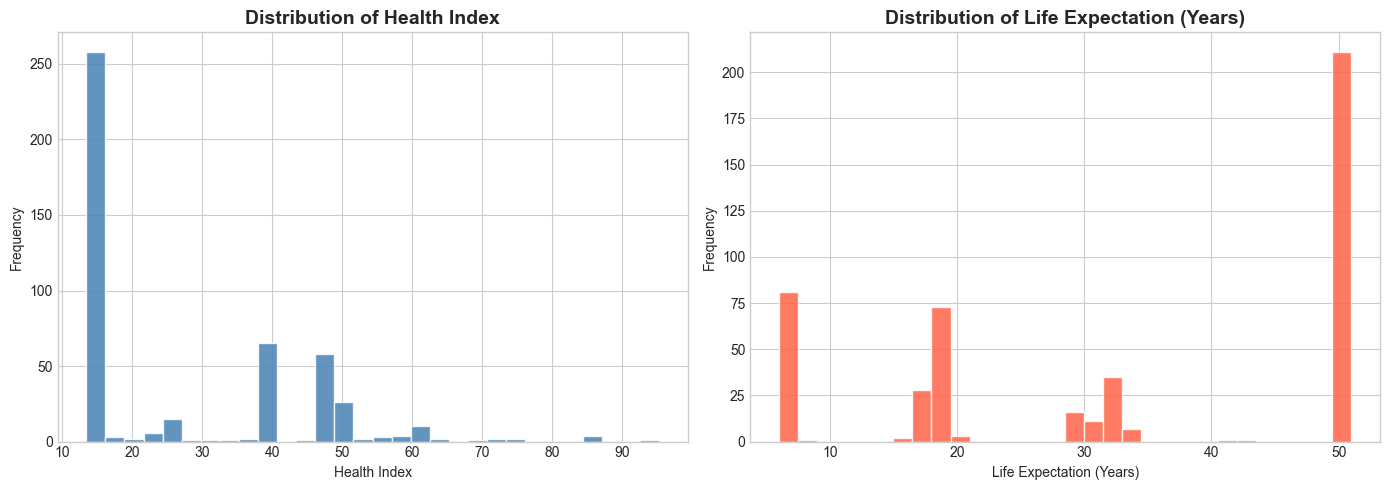

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Health index'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Health Index', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Health Index')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Life expectation'], bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Life Expectation (Years)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Life Expectation (Years)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

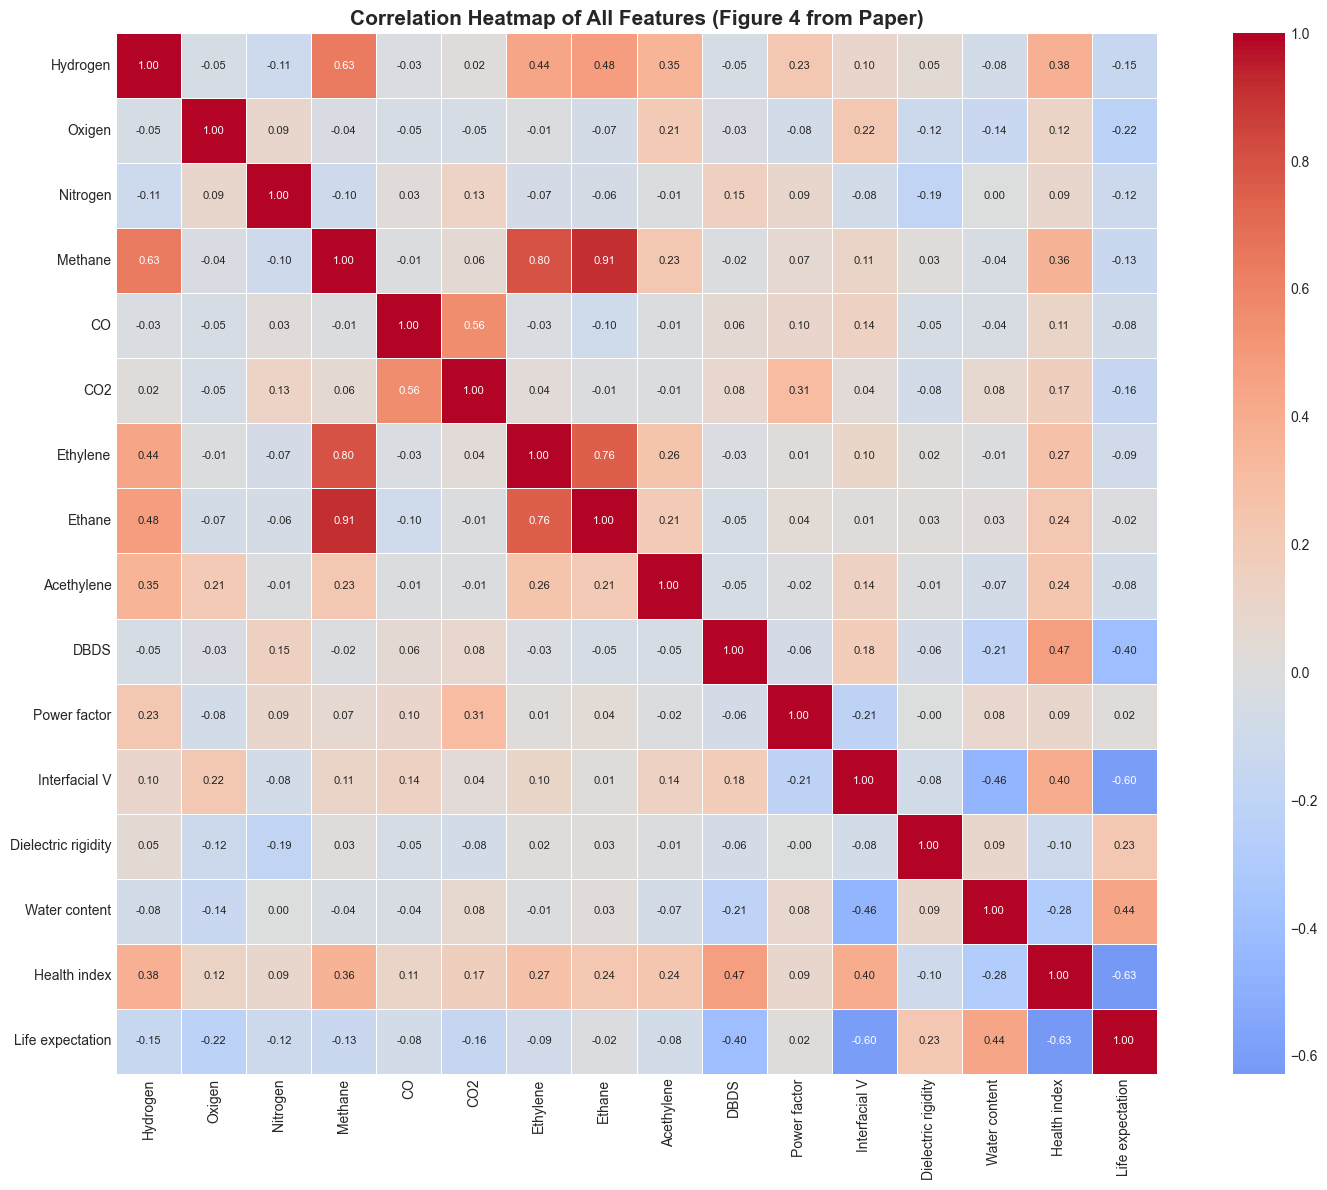

In [7]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Heatmap of All Features (Fig 4 from Paper)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

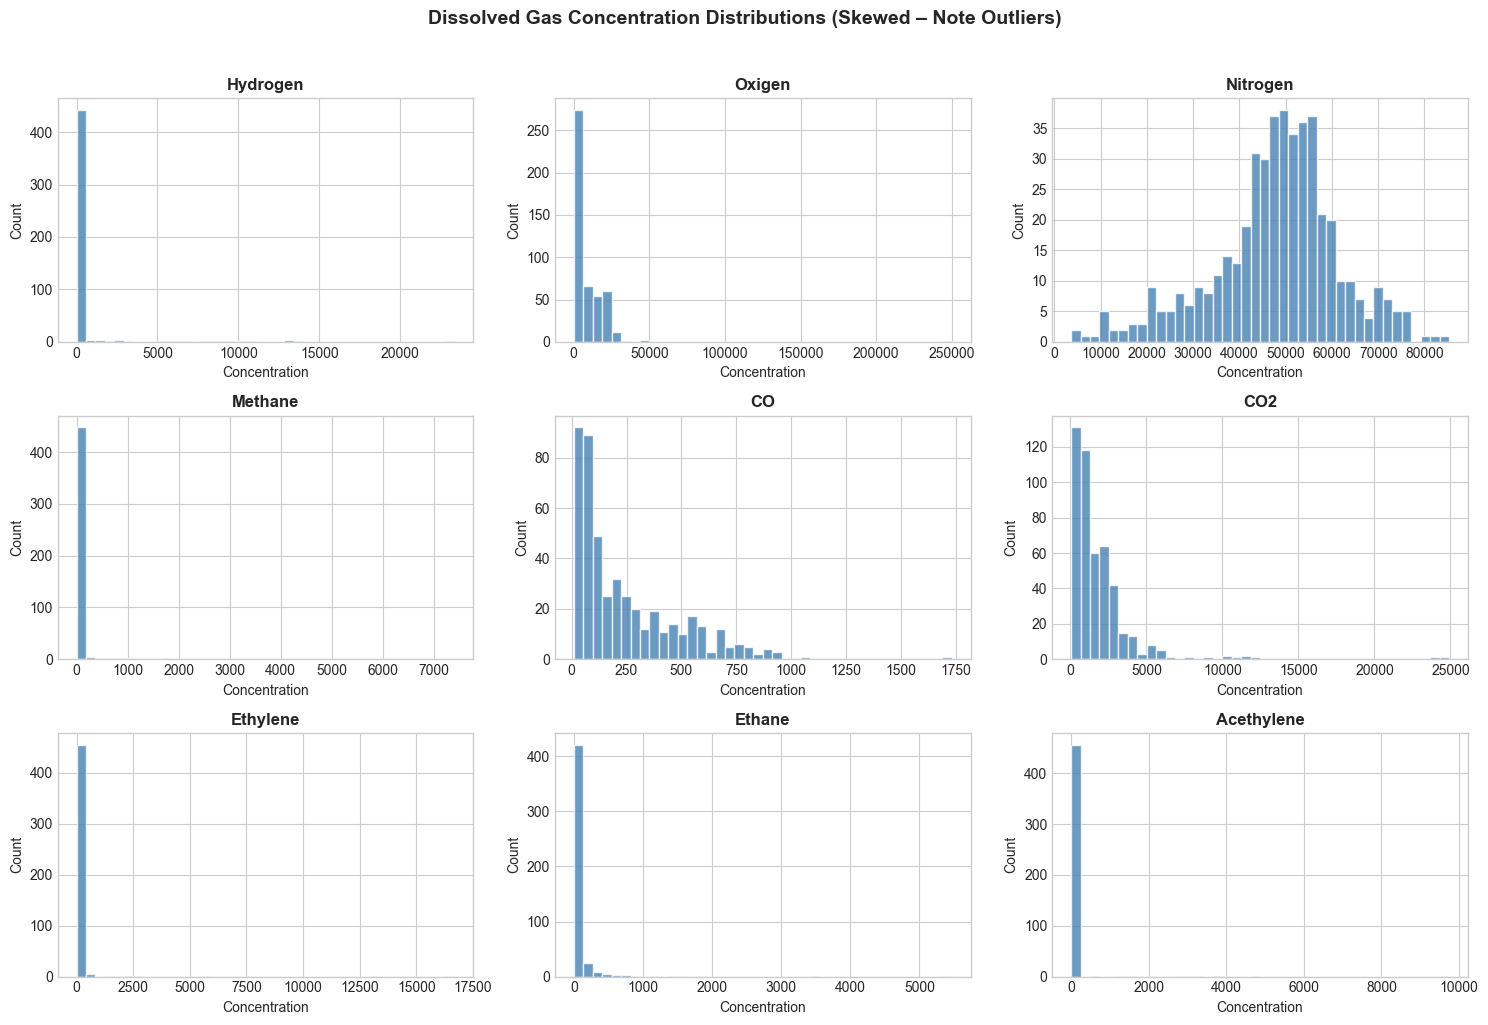

In [8]:
gas_features = ['Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(gas_features):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Count')

plt.suptitle('Dissolved Gas Concentration Distributions (Skewed – Note Outliers)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [9]:
FEATURE_COLS = [c for c in df.columns if c not in ['Health index', 'Life expectation']]
TARGET_HI  = 'Health index'
TARGET_RUL = 'Life expectation'

X = df[FEATURE_COLS].values
y_hi  = df[TARGET_HI].values
y_rul = df[TARGET_RUL].values

Features: ['Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor', 'Interfacial V', 'Dielectric rigidity', 'Water content']
X shape : (470, 14)
y_HI shape : (470,)
y_RUL shape: (470,)


In [10]:
X_train, X_test, yhi_train, yhi_test, yrul_train, yrul_test = train_test_split(
    X, y_hi, y_rul, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}")
print(f"Test  size: {X_test_scaled.shape}")

Train size: (376, 14)
Test  size: (94, 14)


## 5. Helper Functions

In [11]:
def evaluate(name, y_true, y_pred):
    """Compute and display R², RMSE, MSE, MAE."""
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name:35s} | R²={r2:.4f}  MSE={mse:.3f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return dict(model=name, R2=r2, MSE=mse, RMSE=rmse, MAE=mae)


def scatter_actual_vs_pred(y_true, y_pred, title, color='steelblue'):
    """Scatter plot of actual vs predicted values."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, color=color)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title, fontweight='bold')
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.92, f'R²={r2:.4f}\nRMSE={rmse:.3f}', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Baseline Models (Section IV-A: Table 6)
Reproduce baseline performance on the raw full feature set (14 features).

In [12]:
baseline_results = []

baseline_models = {
    'Linear Regression'  : LinearRegression(),
    'Random Forest'      : RandomForestRegressor(random_state=SEED),
    'Gradient Boosting'  : GradientBoostingRegressor(random_state=SEED),
    'LightGBM'           : lgb.LGBMRegressor(random_state=SEED, verbose=-1),
    'XGBoost'            : xgb.XGBRegressor(random_state=SEED, verbosity=0),
}

print("BASELINE MODELS – Health Index (14 features, default params)")

for name, mdl in baseline_models.items():
    mdl.fit(X_train_scaled, yhi_train)
    pred = mdl.predict(X_test_scaled)
    baseline_results.append(evaluate(name, yhi_test, pred))

baseline_df = pd.DataFrame(baseline_results)
baseline_df

BASELINE MODELS – Health Index (14 features, default params)
Linear Regression                   | R²=0.4956  MSE=172.758  RMSE=13.1437  MAE=9.6272
Random Forest                       | R²=0.7424  MSE=88.231  RMSE=9.3931  MAE=6.4159
Gradient Boosting                   | R²=0.7394  MSE=89.249  RMSE=9.4472  MAE=6.3951
LightGBM                            | R²=0.7663  MSE=80.050  RMSE=8.9471  MAE=6.2591
XGBoost                             | R²=0.6650  MSE=114.747  RMSE=10.7120  MAE=7.0217


,model,R2,MSE,RMSE,MAE
0,Linear Regression,0.495583,172.757620,13.143729,9.627168
1,Random Forest,0.742384,88.230686,9.393119,6.415862
2,Gradient Boosting,0.739410,89.249463,9.447193,6.395123
3,LightGBM,0.766269,80.050439,8.947091,6.259140
4,XGBoost,0.664962,114.746958,10.712001,7.021663


## 7. Hyperparameter Tuning via GridSearchCV (Section II-A)
GridSearchCV with 5-fold cross-validation – Algorithm 1 in the paper.

In [13]:
param_grids = {
    'Linear Regression': (
        LinearRegression(),
        {'fit_intercept': [True, False]}
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=SEED),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5]}
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=SEED),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
         'max_depth': [3, 5], 'subsample': [0.8, 1.0]}
    ),
    'LightGBM': (
        lgb.LGBMRegressor(random_state=SEED, verbose=-1),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
         'num_leaves': [31, 63]}
    ),
    'XGBoost': (
        xgb.XGBRegressor(random_state=SEED, verbosity=0),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
         'max_depth': [3, 6]}
    ),
}

best_models = {}
tuned_results = []

print("HYPERPARAMETER-TUNED MODELS – Health Index (GridSearchCV, 5-fold CV)")

for name, (estimator, grid) in param_grids.items():
    gs = GridSearchCV(estimator, grid, cv=5, scoring='neg_mean_squared_error',
                      n_jobs=-1, refit=True)
    gs.fit(X_train_scaled, yhi_train)
    pred = gs.best_estimator_.predict(X_test_scaled)
    best_models[name] = gs.best_estimator_
    row = evaluate(name, yhi_test, pred)
    row['best_params'] = str(gs.best_params_)
    tuned_results.append(row)

tuned_df = pd.DataFrame(tuned_results)
tuned_df[['model', 'R2', 'MSE', 'RMSE', 'MAE']]

HYPERPARAMETER-TUNED MODELS – Health Index (GridSearchCV, 5-fold CV)
Linear Regression                   | R²=0.4956  MSE=172.758  RMSE=13.1437  MAE=9.6272
Random Forest                       | R²=0.7455  MSE=87.159  RMSE=9.3359  MAE=6.2522
Gradient Boosting                   | R²=0.7397  MSE=89.166  RMSE=9.4428  MAE=6.6408
LightGBM                            | R²=0.7733  MSE=77.627  RMSE=8.8106  MAE=5.9557
XGBoost                             | R²=0.7550  MSE=83.897  RMSE=9.1595  MAE=6.4710


,model,R2,MSE,RMSE,MAE
0,Linear Regression,0.495583,172.757620,13.143729,9.627168
1,Random Forest,0.745514,87.158962,9.335896,6.252227
2,Gradient Boosting,0.739652,89.166492,9.442801,6.640764
3,LightGBM,0.773346,77.626583,8.810595,5.955654
4,XGBoost,0.755037,83.897205,9.159542,6.470971


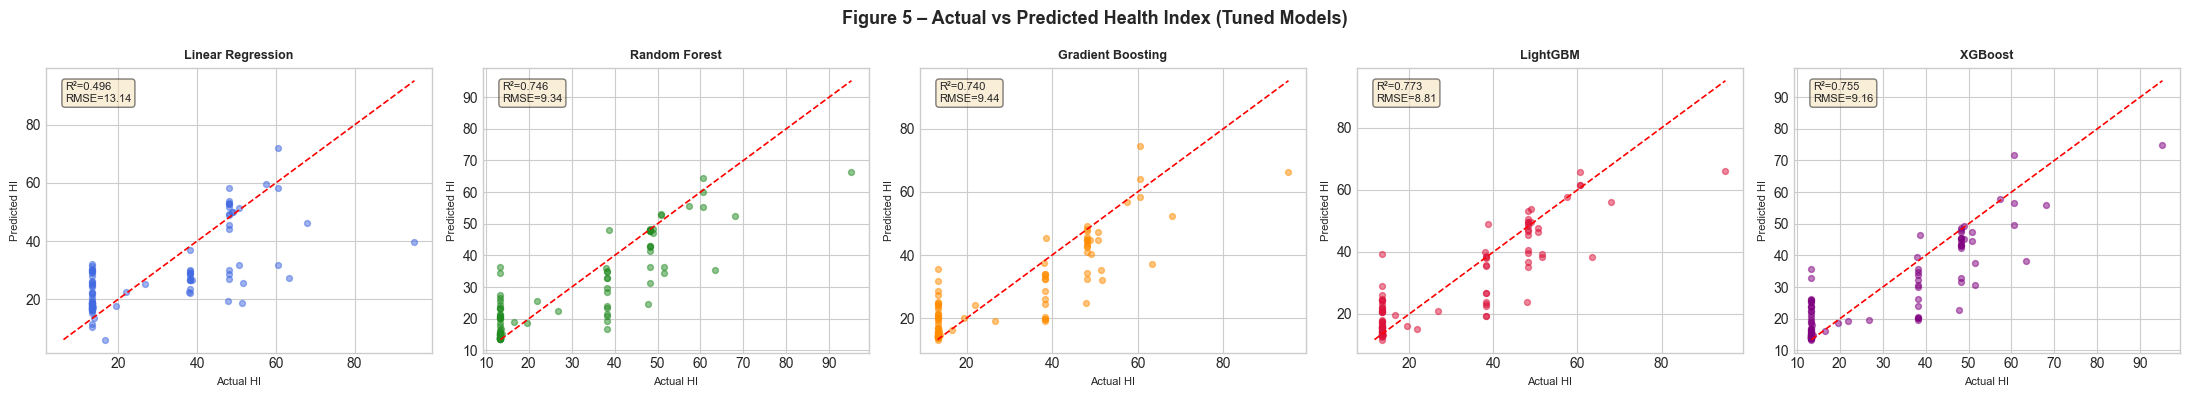

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colors = ['royalblue', 'forestgreen', 'darkorange', 'crimson', 'purple']

for ax, (name, mdl), color in zip(axes, best_models.items(), colors):
    pred = mdl.predict(X_test_scaled)
    ax.scatter(yhi_test, pred, alpha=0.5, s=18, color=color)
    mn, mx = min(yhi_test.min(), pred.min()), max(yhi_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2)
    r2   = r2_score(yhi_test, pred)
    rmse = np.sqrt(mean_squared_error(yhi_test, pred))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual HI', fontsize=8)
    ax.set_ylabel('Predicted HI', fontsize=8)
    ax.text(0.05, 0.88, f'R²={r2:.3f}\nRMSE={rmse:.2f}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)

plt.suptitle('Figure 5 – Actual vs Predicted Health Index (Tuned Models)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

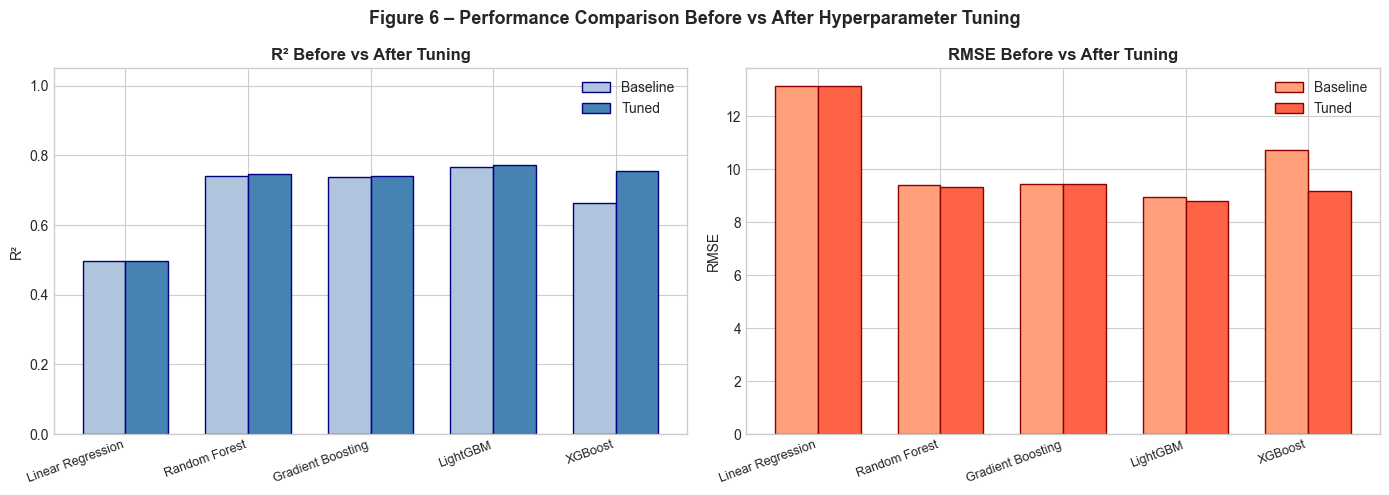

In [15]:
# Comparing R² and RMSE before vs after hyperparameter tuning
model_names = [r['model'] for r in baseline_results]
base_r2   = [r['R2']   for r in baseline_results]
base_rmse = [r['RMSE'] for r in baseline_results]
tune_r2   = [r['R2']   for r in tuned_results]
tune_rmse = [r['RMSE'] for r in tuned_results]

x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, base_r2, width, label='Baseline', color='lightsteelblue', edgecolor='navy')
axes[0].bar(x + width/2, tune_r2, width, label='Tuned', color='steelblue', edgecolor='navy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_title('R² Before vs After Tuning', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

axes[1].bar(x - width/2, base_rmse, width, label='Baseline', color='lightsalmon', edgecolor='darkred')
axes[1].bar(x + width/2, tune_rmse, width, label='Tuned', color='tomato', edgecolor='darkred')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Before vs After Tuning', fontweight='bold')
axes[1].legend()

plt.suptitle('Figure 6 – Performance Comparison Before vs After Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Autoencoder for Feature Reduction (Section II-B)
Implements Algorithm 2 – AE-based feature reduction (bottleneck k < d).

In [16]:
def build_autoencoder(input_dim: int, bottleneck_k: int):
    """
    Build Autoencoder with:
      Encoder: input_dim → Dense → bottleneck_k  (ReLU)
      Decoder: bottleneck_k → Dense → input_dim  (linear)

    Returns (autoencoder, encoder) models.
    Equations (4) and (5) from the paper:
      z = g_phi(x) = sigma(Wx + b)          [Encoder]
      x_hat = h_psi(z) = sigma'(W_hat z + b_hat) [Decoder]
    """
    # Encoder
    inp = keras.Input(shape=(input_dim,), name='input')
    enc = layers.Dense(64, activation='relu', name='enc_hidden')(inp)
    latent = layers.Dense(bottleneck_k, activation='relu', name='bottleneck')(enc)

    # Decoder
    dec = layers.Dense(64, activation='relu', name='dec_hidden')(latent)
    out = layers.Dense(input_dim, activation='linear', name='reconstruction')(dec)

    autoencoder = Model(inp, out, name='Autoencoder')
    encoder     = Model(inp, latent, name='Encoder')

    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


# Paper uses k=9 (Case-IV) as the optimal trade-off
BOTTLENECK_K = 9
ae, encoder = build_autoencoder(input_dim=X_train_scaled.shape[1], bottleneck_k=BOTTLENECK_K)
ae.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_hidden (Dense)                   │ (None, 64)                  │             960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 9)                   │             585 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_hidden (Dense)                   │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Dense)               │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,095 (12.09 KB)

 Trainable params: 3,095 (12.09 KB)

 Non-trainable params: 0 (0.00 B)

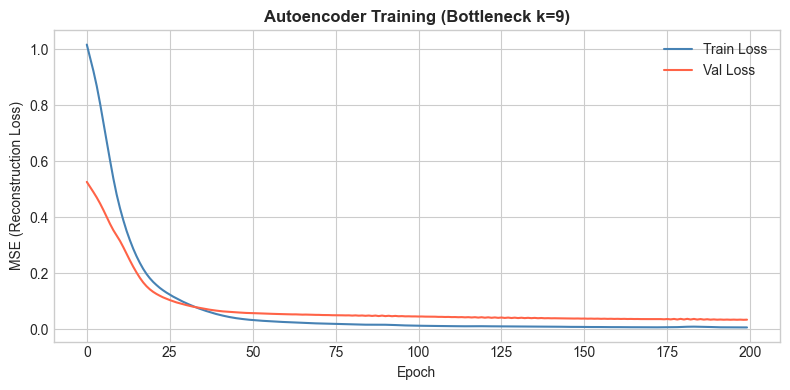

Final train loss: 0.006709
Final val   loss: 0.034416


In [17]:
# Train the Autoencoder (minimise reconstruction loss – Equation 6)
history = ae.fit(
    X_train_scaled, X_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    ]
)

# Plot training loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (Reconstruction Loss)')
ax.set_title(f'Autoencoder Training (Bottleneck k={BOTTLENECK_K})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val   loss: {history.history['val_loss'][-1]:.6f}")

In [18]:
# Extract latent representations z (Step 9 of Algorithm 2 – retain only encoder)
Z_train = encoder.predict(X_train_scaled, verbose=0)
Z_test  = encoder.predict(X_test_scaled,  verbose=0)

print(f"Original feature dim : {X_train_scaled.shape[1]}")
print(f"Reduced latent dim   : {Z_train.shape[1]}  ({(1 - Z_train.shape[1]/X_train_scaled.shape[1])*100:.1f}% reduction)")

Original feature dim : 14
Reduced latent dim   : 9  (35.7% reduction)


## 9. Gradient Boosting Regressor (GBR) – Section II-C
Implements Algorithm 3 – GBR on AE-reduced features.

In [19]:
# GridSearchCV for GBR on AE-reduced features (proposed model)
gbr_param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 5],
    'subsample'     : [0.8, 1.0],
}

gbr_cv = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    gbr_param_grid, cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, refit=True
)
gbr_cv.fit(Z_train, yhi_train)
ae_gbr_model = gbr_cv.best_estimator_

print(f"Best GBR params: {gbr_cv.best_params_}")

# --- Evaluate proposed AE-GBR model ---
pred_ae_gbr = ae_gbr_model.predict(Z_test)

print("\n=" * 50)
print("PROPOSED MODEL: AE + GBR (9 features) – Health Index")
print("=" * 50)
ae_gbr_result = evaluate('AE-GBR (Proposed, k=9)', yhi_test, pred_ae_gbr)

Best GBR params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
PROPOSED MODEL: AE + GBR (9 features) – Health Index
AE-GBR (Proposed, k=9)              | R²=0.5638  MSE=149.400  RMSE=12.2229  MAE=8.5047


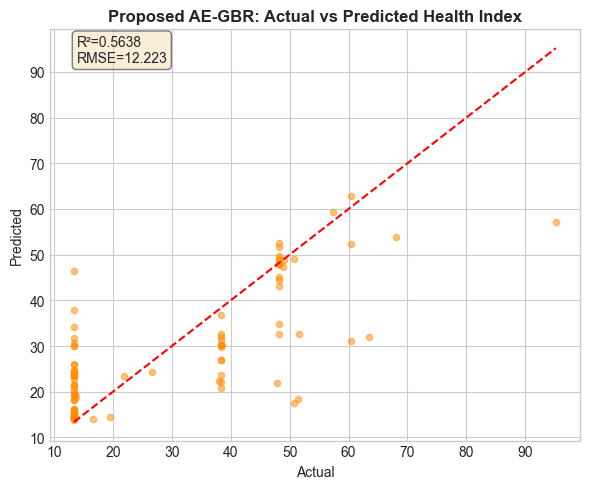

In [20]:
scatter_actual_vs_pred(
    yhi_test, pred_ae_gbr,
    title='Proposed AE-GBR: Actual vs Predicted Health Index',
    color='darkorange'
)

## 10. Feature Reduction Comparison (Section IV-B)
Compare LASSO, RF Feature Importance, PCA, and AE across 5 feature cases.

In [21]:
CASES = {'Case-I (14)': 14, 'Case-II (13)': 13, 'Case-III (11)': 11,
         'Case-IV (9)': 9,  'Case-V (7)': 7}

# ---- Helper: run all regressors on a given (X_tr, X_te) ----
def run_all_regressors(X_tr, X_te, y_tr, y_te):
    regs = {
        'LR'       : LinearRegression(),
        'RF'       : RandomForestRegressor(n_estimators=200, random_state=SEED),
        'GBR'      : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                               max_depth=5, random_state=SEED),
        'LightGBM' : lgb.LGBMRegressor(n_estimators=200, random_state=SEED, verbose=-1),
        'XGBoost'  : xgb.XGBRegressor(n_estimators=200, random_state=SEED, verbosity=0),
    }
    results = {}
    for name, reg in regs.items():
        reg.fit(X_tr, y_tr)
        pred = reg.predict(X_te)
        results[name] = {
            'R2'  : round(r2_score(y_te, pred), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y_te, pred)), 4),
            'MAE' : round(mean_absolute_error(y_te, pred), 4),
        }
    return results

print("Helper functions defined.")

Helper functions defined.


In [22]:
lasso_sel = Lasso(alpha=0.01, max_iter=5000)
lasso_sel.fit(X_train_scaled, yhi_train)
lasso_importance = np.abs(lasso_sel.coef_)
lasso_ranked = np.argsort(lasso_importance)[::-1]

print("LASSO-ranked features (most → least important):")
for rank, idx in enumerate(lasso_ranked):
    print(f"  {rank+1:2d}. {FEATURE_COLS[idx]:20s}  coef={lasso_importance[idx]:.4f}")

LASSO-ranked features (most → least important):
   1. DBDS                  coef=6.9675
   2. Hydrogen              coef=5.0548
   3. Interfacial V         coef=4.3645
   4. Ethane                coef=2.7620
   5. Methane               coef=2.7619
   6. Acethylene            coef=1.9983
   7. Nitrogen              coef=1.4653
   8. Power factor          coef=1.3158
   9. Dielectric rigidity   coef=1.2573
  10. Oxigen                coef=1.0987
  11. Water content         coef=0.5568
  12. Ethylene              coef=0.4252
  13. CO2                   coef=0.1876
  14. CO                    coef=0.0379


In [23]:
lasso_results_table = {}

for case_name, k in CASES.items():
    selected = lasso_ranked[:k]
    Xtr = X_train_scaled[:, selected]
    Xte = X_test_scaled[:, selected]
    lasso_results_table[case_name] = run_all_regressors(Xtr, Xte, yhi_train, yhi_test)

# Display R² summary
r2_lasso = pd.DataFrame(
    {case: {model: v['R2'] for model, v in res.items()}
     for case, res in lasso_results_table.items()}
)
print("\nTable 7 – LASSO Feature Reduction (R² values)")
r2_lasso


Table 7 – LASSO Feature Reduction (R² values)


,Case-I (14),Case-II (13),Case-III (11),Case-IV (9),Case-V (7)
LR,0.4956,0.4956,0.4918,0.4820,0.4203
RF,0.7465,0.7431,0.7233,0.7345,0.7551
GBR,0.6997,0.6997,0.6758,0.7007,0.7294
LightGBM,0.7632,0.7418,0.7543,0.7344,0.7245
XGBoost,0.6635,0.7088,0.6476,0.6681,0.7160


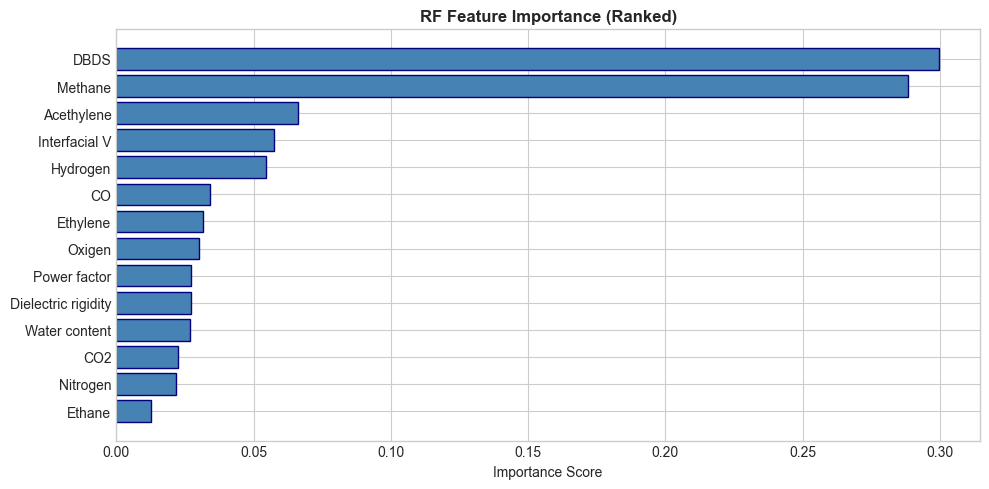


Table 8 – RF Feature Importance Reduction (R² values)


,Case-I (14),Case-II (13),Case-III (11),Case-IV (9),Case-V (7)
LR,0.4956,0.5114,0.5214,0.5364,0.4554
RF,0.7478,0.7501,0.7414,0.7617,0.7642
GBR,0.7093,0.7099,0.7110,0.6927,0.7506
LightGBM,0.7632,0.7638,0.7812,0.7416,0.7471
XGBoost,0.6514,0.6731,0.6488,0.7304,0.6739


In [24]:
rf_imp_model = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_imp_model.fit(X_train_scaled, yhi_train)
rf_importance = rf_imp_model.feature_importances_
rf_ranked = np.argsort(rf_importance)[::-1]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([FEATURE_COLS[i] for i in rf_ranked], rf_importance[rf_ranked],
        color='steelblue', edgecolor='navy')
ax.set_xlabel('Importance Score')
ax.set_title('RF Feature Importance (Ranked)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

rf_results_table = {}
for case_name, k in CASES.items():
    selected = rf_ranked[:k]
    Xtr = X_train_scaled[:, selected]
    Xte = X_test_scaled[:, selected]
    rf_results_table[case_name] = run_all_regressors(Xtr, Xte, yhi_train, yhi_test)

r2_rf = pd.DataFrame(
    {case: {model: v['R2'] for model, v in res.items()}
     for case, res in rf_results_table.items()}
)
print("\nTable 8 – RF Feature Importance Reduction (R² values)")
r2_rf

In [25]:
pca_results_table = {}

for case_name, k in CASES.items():
    pca = PCA(n_components=k, random_state=SEED)
    Xtr = pca.fit_transform(X_train_scaled)
    Xte = pca.transform(X_test_scaled)
    pca_results_table[case_name] = run_all_regressors(Xtr, Xte, yhi_train, yhi_test)

r2_pca = pd.DataFrame(
    {case: {model: v['R2'] for model, v in res.items()}
     for case, res in pca_results_table.items()}
)
print("Table 9 – PCA-based Feature Reduction (R² values)")
r2_pca

Table 9 – PCA-based Feature Reduction (R² values)


,Case-I (14),Case-II (13),Case-III (11),Case-IV (9),Case-V (7)
LR,0.4956,0.4762,0.5802,0.5574,0.4800
RF,0.5811,0.5719,0.5777,0.5722,0.5640
GBR,0.5648,0.5611,0.5388,0.5368,0.4887
LightGBM,0.5551,0.5381,0.5673,0.5407,0.4802
XGBoost,0.4456,0.4837,0.4426,0.4846,0.4354


In [26]:
ae_results_table = {}

for case_name, k in CASES.items():
    ae_k, enc_k = build_autoencoder(X_train_scaled.shape[1], bottleneck_k=k)
    ae_k.fit(
        X_train_scaled, X_train_scaled,
        epochs=150, batch_size=32, validation_split=0.1, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )
    Ztr = enc_k.predict(X_train_scaled, verbose=0)
    Zte = enc_k.predict(X_test_scaled,  verbose=0)
    ae_results_table[case_name] = run_all_regressors(Ztr, Zte, yhi_train, yhi_test)
    print(f"  {case_name} (k={k}) done.")

r2_ae = pd.DataFrame(
    {case: {model: v['R2'] for model, v in res.items()}
     for case, res in ae_results_table.items()}
)
print("\nTable 10 – Autoencoder-based Feature Reduction (R² values)")
r2_ae

  Case-I (14) (k=14) done.
  Case-II (13) (k=13) done.
  Case-III (11) (k=11) done.
  Case-IV (9) (k=9) done.
  Case-V (7) (k=7) done.

Table 10 – Autoencoder-based Feature Reduction (R² values)


,Case-I (14),Case-II (13),Case-III (11),Case-IV (9),Case-V (7)
LR,0.2320,0.4137,0.5678,0.5744,0.4989
RF,0.5062,0.4121,0.5736,0.5458,0.5350
GBR,0.5142,0.4338,0.5583,0.5672,0.4907
LightGBM,0.5445,0.4182,0.5292,0.5521,0.4981
XGBoost,0.4702,0.4001,0.4398,0.5137,0.4403


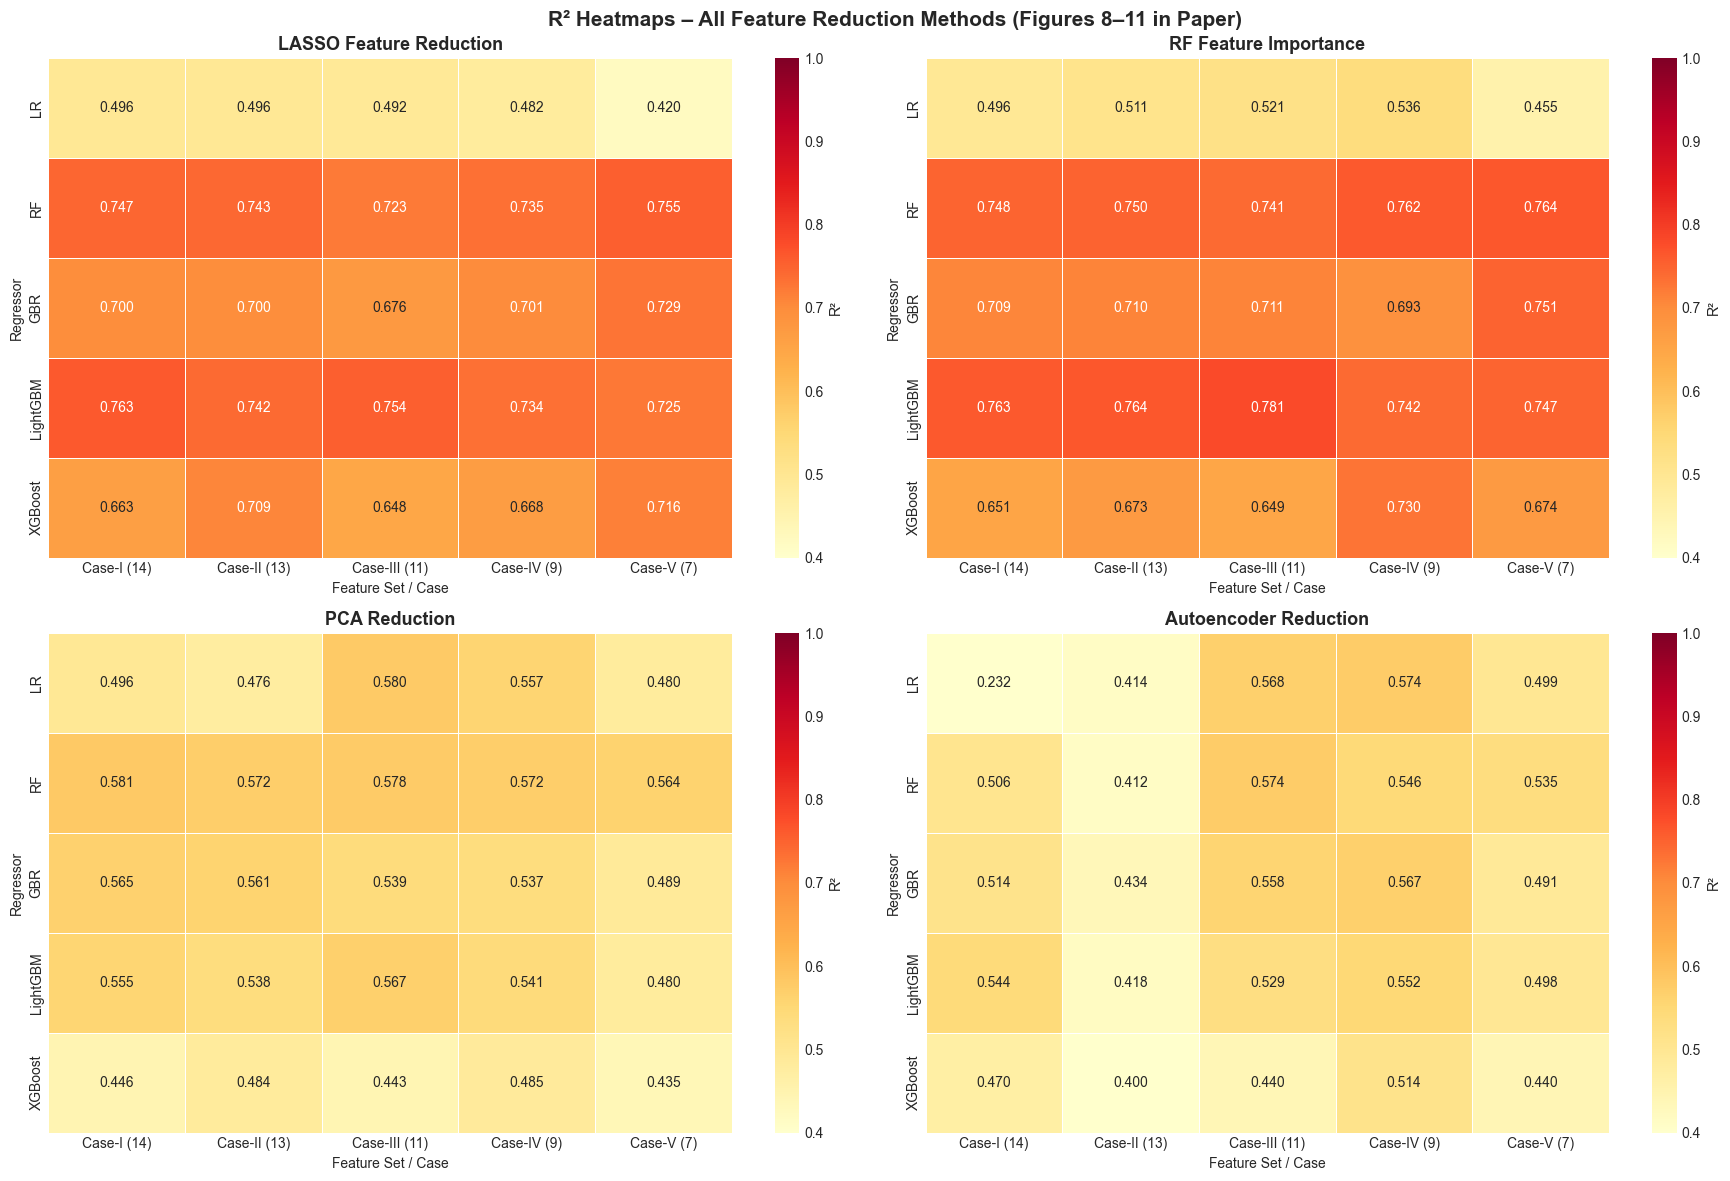

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

tables = [
    (r2_lasso, 'LASSO Feature Reduction'),
    (r2_rf,    'RF Feature Importance'),
    (r2_pca,   'PCA Reduction'),
    (r2_ae,    'Autoencoder Reduction'),
]

for ax, (r2_df, title) in zip(axes.flat, tables):
    sns.heatmap(
        r2_df.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
        vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5, cbar_kws={'label': 'R²'}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Set / Case')
    ax.set_ylabel('Regressor')

plt.suptitle('R² Heatmaps – All Feature Reduction Methods (Figures 8–11 in Paper)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Proposed AE-GBR vs Deep Learning Baselines (Table 11)

In [28]:
def build_fnn(input_dim):
    mdl = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ], name='FNN')
    mdl.compile(optimizer='adam', loss='mse')
    return mdl

def build_dnn(input_dim):
    mdl = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1)
    ], name='DNN')
    mdl.compile(optimizer='adam', loss='mse')
    return mdl

def build_lstm(input_dim):
    mdl = keras.Sequential([
        layers.Input(shape=(1, input_dim)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(1)
    ], name='LSTM')
    mdl.compile(optimizer='adam', loss='mse')
    return mdl


CB = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

# FNN
fnn = build_fnn(X_train_scaled.shape[1])
fnn.fit(X_train_scaled, yhi_train, epochs=200, batch_size=32,
        validation_split=0.1, verbose=0, callbacks=[CB])
fnn_pred = fnn.predict(X_test_scaled, verbose=0).flatten()

# DNN
dnn = build_dnn(X_train_scaled.shape[1])
dnn.fit(X_train_scaled, yhi_train, epochs=200, batch_size=32,
        validation_split=0.1, verbose=0, callbacks=[CB])
dnn_pred = dnn.predict(X_test_scaled, verbose=0).flatten()

# LSTM (needs 3D input)
lstm = build_lstm(X_train_scaled.shape[1])
lstm.fit(X_train_scaled[:, np.newaxis, :], yhi_train, epochs=200, batch_size=32,
         validation_split=0.1, verbose=0, callbacks=[CB])
lstm_pred = lstm.predict(X_test_scaled[:, np.newaxis, :], verbose=0).flatten()

# GBR full features
gbr_full = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                     max_depth=5, random_state=SEED)
gbr_full.fit(X_train_scaled, yhi_train)
gbr_full_pred = gbr_full.predict(X_test_scaled)

print("=" * 85)
print("Table 11 – Comparison with Deep Learning Baselines")
print("=" * 85)

dl_results = []
dl_results.append(evaluate('FNN (14 features)',       yhi_test, fnn_pred))
dl_results.append(evaluate('DNN (14 features)',       yhi_test, dnn_pred))
dl_results.append(evaluate('LSTM (14 features)',      yhi_test, lstm_pred))
dl_results.append(evaluate('GBR (14 features)',       yhi_test, gbr_full_pred))
dl_results.append(evaluate('AE-GBR (9 features) ★',  yhi_test, pred_ae_gbr))

dl_df = pd.DataFrame(dl_results)
dl_df[['model', 'R2', 'RMSE', 'MSE', 'MAE']]

Table 11 – Comparison with Deep Learning Baselines
FNN (14 features)                   | R²=0.6060  MSE=134.941  RMSE=11.6164  MAE=8.6592
DNN (14 features)                   | R²=-1.8844  MSE=987.882  RMSE=31.4306  MAE=26.3109
LSTM (14 features)                  | R²=-2.4382  MSE=1177.535  RMSE=34.3152  MAE=28.9029
GBR (14 features)                   | R²=0.7149  MSE=97.660  RMSE=9.8823  MAE=6.3916
AE-GBR (9 features) ★               | R²=0.5638  MSE=149.400  RMSE=12.2229  MAE=8.5047


,model,R2,RMSE,MSE,MAE
0,FNN (14 features),0.606001,11.616395,134.940623,8.659189
1,DNN (14 features),-1.884413,31.430586,987.881746,26.310880
2,LSTM (14 features),-2.438161,34.315223,1177.534505,28.902940
3,GBR (14 features),0.714853,9.882310,97.660048,6.391650
4,AE-GBR (9 features) ★,0.563784,12.222911,149.399548,8.504707


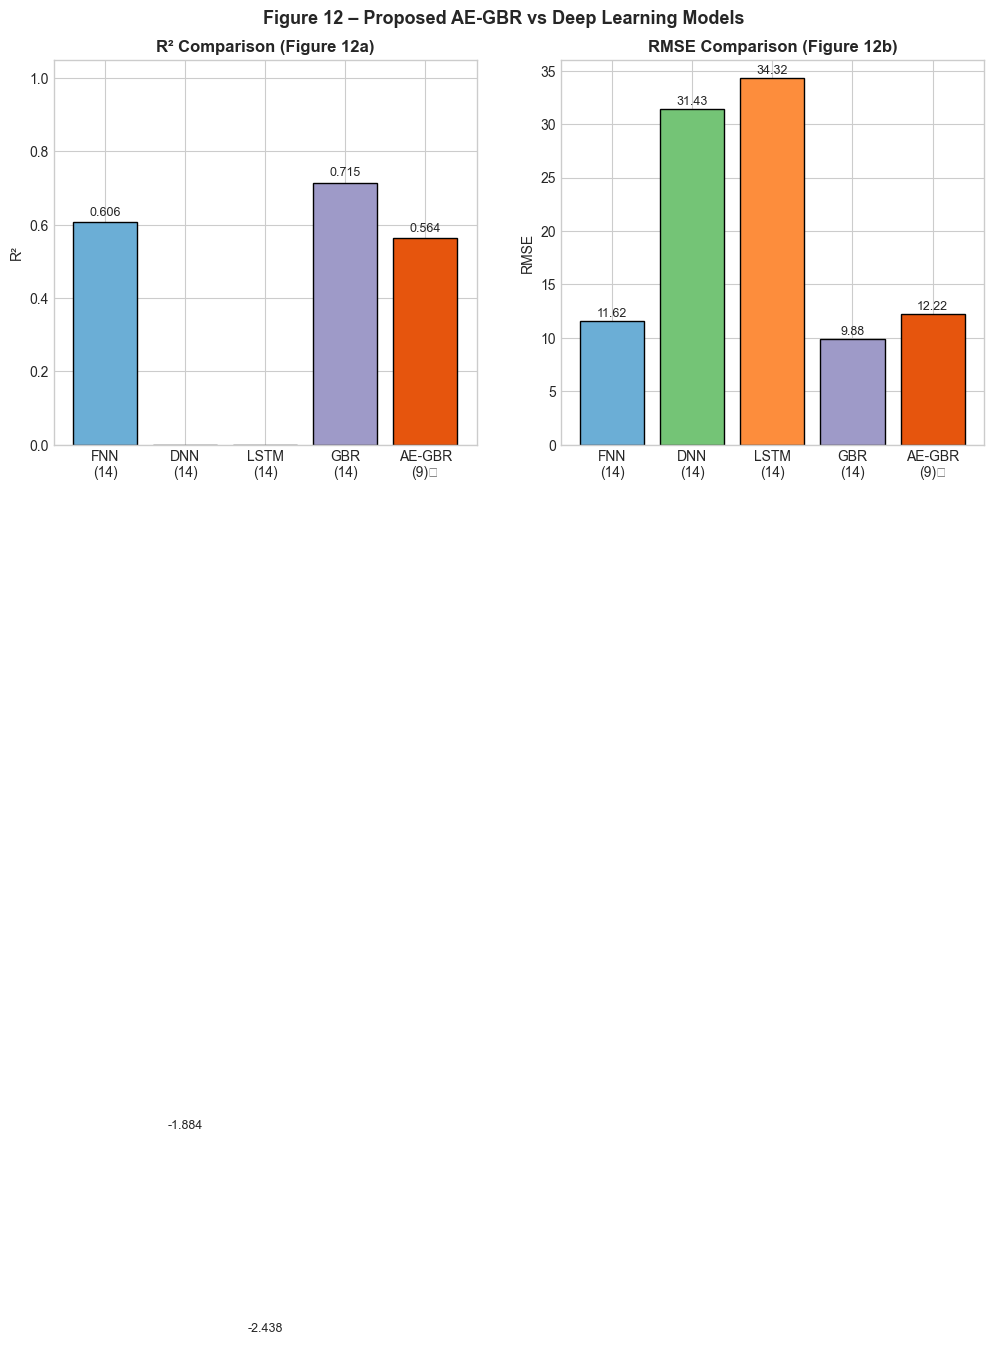

In [29]:
# Figure 12 – R² and RMSE comparison
labels = ['FNN\n(14)', 'DNN\n(14)', 'LSTM\n(14)', 'GBR\n(14)', 'AE-GBR\n(9)★']
r2s    = [r['R2']   for r in dl_results]
rmses  = [r['RMSE'] for r in dl_results]
colors = ['#6baed6', '#74c476', '#fd8d3c', '#9e9ac8', '#e6550d']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars0 = axes[0].bar(labels, r2s, color=colors, edgecolor='black')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R²')
axes[0].set_title('R² Comparison (Figure 12a)', fontweight='bold')
for bar, val in zip(bars0, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

bars1 = axes[1].bar(labels, rmses, color=colors, edgecolor='black')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison (Figure 12b)', fontweight='bold')
for bar, val in zip(bars1, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Figure 12 – Proposed AE-GBR vs Deep Learning Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Remaining Lifespan (RUL) Prediction (Section IV-F)

In [30]:
# Use same AE (trained on HI task) for RUL – same latent space as paper
rul_results_table = {}

print("REMAINING LIFESPAN (RUL) PREDICTION – AE + GBR")

for case_name, k in CASES.items():
    ae_k, enc_k = build_autoencoder(X_train_scaled.shape[1], bottleneck_k=k)
    ae_k.fit(
        X_train_scaled, X_train_scaled,
        epochs=150, batch_size=32, validation_split=0.1, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )
    Ztr = enc_k.predict(X_train_scaled, verbose=0)
    Zte = enc_k.predict(X_test_scaled,  verbose=0)
    rul_results_table[case_name] = run_all_regressors(Ztr, Zte, yrul_train, yrul_test)
    print(f"  {case_name} (k={k}) done.")

r2_rul = pd.DataFrame(
    {case: {model: v['R2'] for model, v in res.items()}
     for case, res in rul_results_table.items()}
)
rmse_rul = pd.DataFrame(
    {case: {model: v['RMSE'] for model, v in res.items()}
     for case, res in rul_results_table.items()}
)

print("\nTable 16 – RUL Prediction R² values (AE feature reduction)")
r2_rul

REMAINING LIFESPAN (RUL) PREDICTION – AE + GBR
  Case-I (14) (k=14) done.
  Case-II (13) (k=13) done.
  Case-III (11) (k=11) done.
  Case-IV (9) (k=9) done.
  Case-V (7) (k=7) done.

Table 16 – RUL Prediction R² values (AE feature reduction)


,Case-I (14),Case-II (13),Case-III (11),Case-IV (9),Case-V (7)
LR,0.4830,0.4001,0.5114,0.3571,0.4280
RF,0.6782,0.6774,0.6469,0.6946,0.6255
GBR,0.6289,0.6656,0.5643,0.5847,0.5655
LightGBM,0.6744,0.6766,0.6713,0.5864,0.5804
XGBoost,0.5846,0.7347,0.5539,0.6250,0.5684


PROPOSED MODEL: AE + GBR (9 features) – Life Expectation
AE-GBR RUL (k=9)                    | R²=0.6145  MSE=109.581  RMSE=10.4681  MAE=8.0407


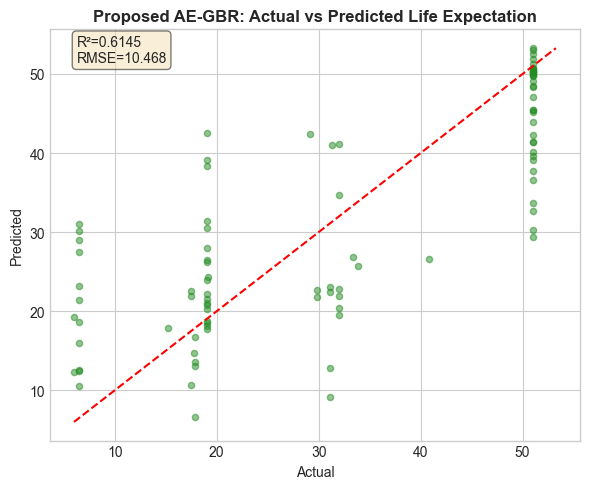

In [31]:
ae9, enc9 = build_autoencoder(X_train_scaled.shape[1], bottleneck_k=9)
ae9.fit(
    X_train_scaled, X_train_scaled,
    epochs=150, batch_size=32, validation_split=0.1, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
Z9_train = enc9.predict(X_train_scaled, verbose=0)
Z9_test  = enc9.predict(X_test_scaled,  verbose=0)

gbr_rul = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
gbr_rul.fit(Z9_train, yrul_train)
pred_rul = gbr_rul.best_estimator_.predict(Z9_test)

print("PROPOSED MODEL: AE + GBR (9 features) – Life Expectation")
evaluate('AE-GBR RUL (k=9)', yrul_test, pred_rul)

scatter_actual_vs_pred(
    yrul_test, pred_rul,
    title='Proposed AE-GBR: Actual vs Predicted Life Expectation',
    color='forestgreen'
)

## 13. Robustness Analysis (Table 13 – Noise Injection & Missing Features)

In [32]:
robustness_results = []

# Baseline (clean)
r2c   = r2_score(yhi_test, pred_ae_gbr)
rmsec = np.sqrt(mean_squared_error(yhi_test, pred_ae_gbr))
robustness_results.append({'Scenario': 'Baseline (clean)', 'Setting': '—',
                            'R2': r2c, 'RMSE': rmsec})

# Noise injection (5%, 10%, 20%)
for noise_pct in [0.05, 0.10, 0.20]:
    X_noisy = X_test_scaled + noise_pct * np.random.randn(*X_test_scaled.shape)
    Z_noisy = encoder.predict(X_noisy, verbose=0)
    pred_n  = ae_gbr_model.predict(Z_noisy)
    robustness_results.append({
        'Scenario': 'Noise Injection',
        'Setting' : f'{int(noise_pct*100)}%',
        'R2'      : round(r2_score(yhi_test, pred_n), 4),
        'RMSE'    : round(np.sqrt(mean_squared_error(yhi_test, pred_n)), 4),
    })

# Missing features (1, 2, 3 features zeroed out)
for n_missing in [1, 2, 3]:
    X_missing = X_test_scaled.copy()
    missing_idx = np.random.choice(X_test_scaled.shape[1], n_missing, replace=False)
    X_missing[:, missing_idx] = 0
    Z_miss  = encoder.predict(X_missing, verbose=0)
    pred_m  = ae_gbr_model.predict(Z_miss)
    robustness_results.append({
        'Scenario': 'Missing Feature',
        'Setting' : str(n_missing),
        'R2'      : round(r2_score(yhi_test, pred_m), 4),
        'RMSE'    : round(np.sqrt(mean_squared_error(yhi_test, pred_m)), 4),
    })

rob_df = pd.DataFrame(robustness_results)
print("Table 13 – Robustness Analysis")
rob_df

Table 13 – Robustness Analysis


,Scenario,Setting,R2,RMSE
0,Baseline (clean),—,0.563784,12.222911
1,Noise Injection,5%,0.577100,12.035000
2,Noise Injection,10%,0.555200,12.342300
3,Noise Injection,20%,0.462500,13.568300
4,Missing Feature,1,0.556000,12.330900
5,Missing Feature,2,0.382500,14.542800
6,Missing Feature,3,0.314700,15.320300


## 14. Multi-Seed Repeatability (Table 14)

In [33]:
SEEDS = [42, 11, 77, 101, 202, 303, 404, 505, 606, 707]
repeat_results = []

for seed in SEEDS:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    Xtr, Xte, ytr, yte = train_test_split(X, y_hi, test_size=0.2, random_state=seed)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    ae_s, enc_s = build_autoencoder(Xtr_s.shape[1], bottleneck_k=9)
    ae_s.fit(
        Xtr_s, Xtr_s, epochs=150, batch_size=32,
        validation_split=0.1, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )
    Ztr_s = enc_s.predict(Xtr_s, verbose=0)
    Zte_s = enc_s.predict(Xte_s, verbose=0)

    gbr_s = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                      max_depth=5, random_state=seed)
    gbr_s.fit(Ztr_s, ytr)
    pred_s = gbr_s.predict(Zte_s)

    repeat_results.append({
        'Seed': seed,
        'R2'  : round(r2_score(yte, pred_s), 4),
        'RMSE': round(np.sqrt(mean_squared_error(yte, pred_s)), 4),
    })
    print(f"  Seed {seed:3d} → R²={repeat_results[-1]['R2']:.4f}  RMSE={repeat_results[-1]['RMSE']:.4f}")

rep_df = pd.DataFrame(repeat_results)
print(f"\nAverage R²  : {rep_df['R2'].mean():.4f} ± {rep_df['R2'].std():.4f}")
print(f"Average RMSE: {rep_df['RMSE'].mean():.4f} ± {rep_df['RMSE'].std():.4f}")
rep_df

  Seed  42 → R²=0.4162  RMSE=14.1405
  Seed  11 → R²=0.3178  RMSE=14.4101
  Seed  77 → R²=0.3700  RMSE=14.2980
  Seed 101 → R²=0.4691  RMSE=12.6017
  Seed 202 → R²=0.3942  RMSE=12.7212
  Seed 303 → R²=0.6103  RMSE=11.0391
  Seed 404 → R²=0.4781  RMSE=12.6952
  Seed 505 → R²=0.4704  RMSE=13.7216
  Seed 606 → R²=0.4592  RMSE=13.6389
  Seed 707 → R²=0.5515  RMSE=11.9192

Average R²  : 0.4537 ± 0.0854
Average RMSE: 13.1185 ± 1.1108


,Seed,R2,RMSE
0,42,0.4162,14.1405
1,11,0.3178,14.4101
2,77,0.3700,14.2980
3,101,0.4691,12.6017
4,202,0.3942,12.7212
5,303,0.6103,11.0391
6,404,0.4781,12.6952
7,505,0.4704,13.7216
8,606,0.4592,13.6389
9,707,0.5515,11.9192


## 15. Final Summary – Proposed AE-GBR vs Reference (Table 15)

Table 15 – Proposed vs Reference Study
                   Method    Features       R2      RMSE      MAE
LightGBM + RobustEM [ref]   14 (Full) 0.970000  6.230000 3.590000
  AE + GBR (9 features) ★ 9 (Reduced) 0.563784 12.222911 8.504707


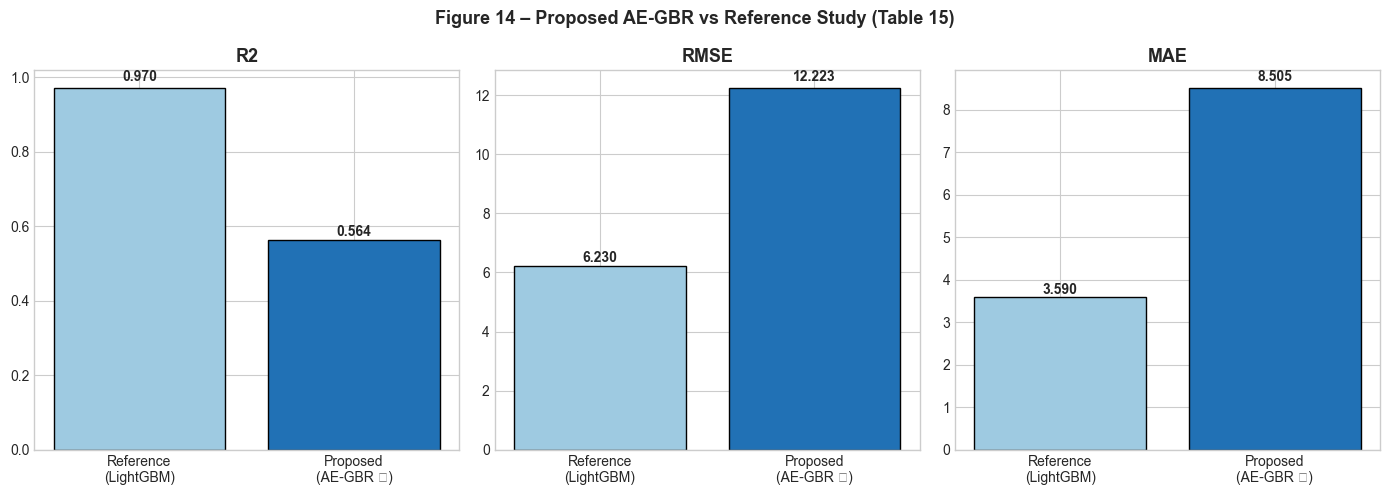

In [34]:
summary_data = {
    'Method'         : ['LightGBM + RobustEM [ref]', 'AE + GBR (9 features) ★'],
    'Features'       : ['14 (Full)', '9 (Reduced)'],
    'R2'             : [0.970, ae_gbr_result['R2']],
    'RMSE'           : [6.230, ae_gbr_result['RMSE']],
    'MAE'            : [3.590, ae_gbr_result['MAE']],
}
summary_df = pd.DataFrame(summary_data)
print("Table 15 – Proposed vs Reference Study")
print(summary_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['R2', 'RMSE', 'MAE']
colors_bar = ['#d73027', '#e6550d']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(summary_df['Method'], summary_df[metric],
                  color=['#9ecae1', '#2171b5'], edgecolor='black')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xticks(range(len(summary_df)))
    ax.set_xticklabels(['Reference\n(LightGBM)', 'Proposed\n(AE-GBR ★)'],
                       fontsize=10)
    for bar, val in zip(bars, summary_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val * 1.02, f'{val:.3f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 14 – Proposed AE-GBR vs Reference Study (Table 15)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. HI vs RUL Comparison (Figure 16 – Radar Chart)

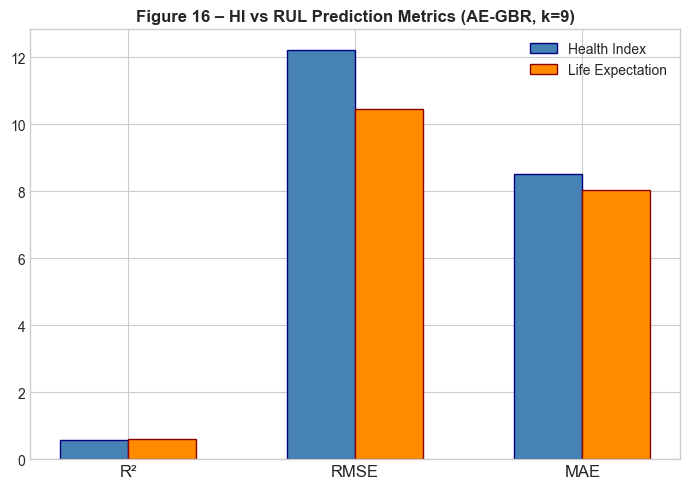

Health Index  → R²=0.5638, RMSE=12.2229, MAE=8.5047
Life Expect.  → R²=0.6145, RMSE=10.4681, MAE=8.0407


In [35]:
from matplotlib.patches import FancyArrowPatch

hi_metrics  = [r2_score(yhi_test, pred_ae_gbr),
               np.sqrt(mean_squared_error(yhi_test, pred_ae_gbr)),
               mean_absolute_error(yhi_test, pred_ae_gbr)]

rul_metrics = [r2_score(yrul_test, pred_rul),
               np.sqrt(mean_squared_error(yrul_test, pred_rul)),
               mean_absolute_error(yrul_test, pred_rul)]

fig, ax = plt.subplots(figsize=(7, 5))
x   = np.arange(3)
w   = 0.3

ax.bar(x - w/2, hi_metrics,  w, label='Health Index',     color='steelblue',  edgecolor='navy')
ax.bar(x + w/2, rul_metrics, w, label='Life Expectation', color='darkorange', edgecolor='darkred')
ax.set_xticks(x)
ax.set_xticklabels(['R²', 'RMSE', 'MAE'], fontsize=12)
ax.set_title('Figure 16 – HI vs RUL Prediction Metrics (AE-GBR, k=9)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Health Index  → R²={hi_metrics[0]:.4f}, RMSE={hi_metrics[1]:.4f}, MAE={hi_metrics[2]:.4f}")
print(f"Life Expect.  → R²={rul_metrics[0]:.4f}, RMSE={rul_metrics[1]:.4f}, MAE={rul_metrics[2]:.4f}")